# Sales Forecasting and Demand Intelligence System

## Task 1 - Data Loading, Merging and Deep Exploration

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [146]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [147]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

In [148]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [149]:
df.shape

(9800, 18)

In [150]:
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [151]:
# Extracting time features
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Week']       = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['Order Date'].dt.dayofweek
df['Quarter']    = df['Order Date'].dt.quarter

In [152]:
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Fall'

In [153]:
df['Season'] = df['Month'].apply(get_season)

In [154]:
df[['Order Date', 'Year', 'Month', 'Week', 'Quarter', 'Season']].head()

,Order Date,Year,Month,Week,Quarter,Season
0,2017-11-08,2017,11,45,4,Fall
1,2017-11-08,2017,11,45,4,Fall
2,2017-06-12,2017,6,24,2,Summer
3,2016-10-11,2016,10,41,4,Fall
4,2016-10-11,2016,10,41,4,Fall


In [155]:
# Missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Postal Code missing is irrelevant for sales forecasting so keeping as it is.

In [156]:
df.duplicated().sum()

np.int64(0)

In [157]:
# Monthly aggregation
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)
monthly_sales.head()

,Year,Month,Sales,Date
0,2015,1,14205.707,2015-01-01
1,2015,2,4519.892,2015-02-01
2,2015,3,55205.797,2015-03-01
3,2015,4,27906.855,2015-04-01
4,2015,5,23644.303,2015-05-01


In [158]:
monthly_sales.shape

(48, 4)

In [159]:
# Weekly aggregation
weekly_sales = df.groupby(['Year', 'Week'])['Sales'].sum().reset_index()
weekly_sales = weekly_sales.sort_values(['Year', 'Week']).reset_index(drop=True)

In [160]:
weekly_sales.head()

,Year,Week,Sales
0,2015,1,304.508
1,2015,2,4619.108
2,2015,3,4130.533
3,2015,4,3092.544
4,2015,5,2527.914


In [161]:
weekly_sales.shape

(210, 3)

In [162]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

In [163]:
category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [164]:
import os
os.makedirs('charts', exist_ok=True)

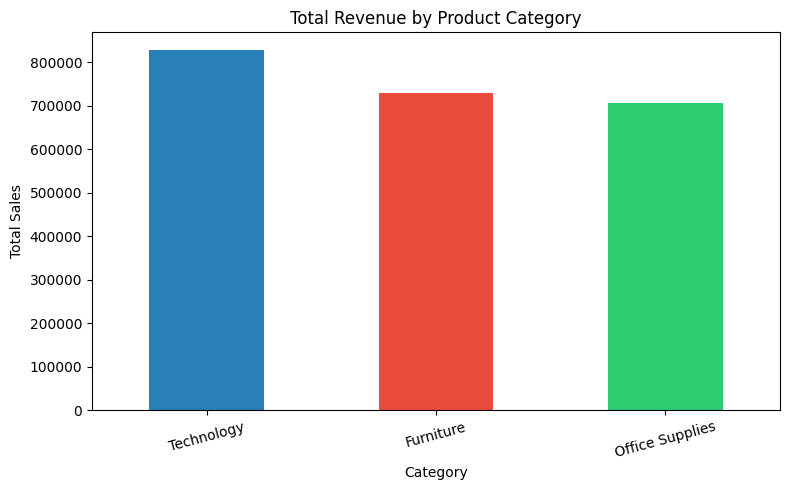

In [165]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color=['#2980B9', '#E74C3C', '#2ECC71'])
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()

In [166]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()

In [167]:
region_yearly

Year,2015,2016,2017,2018
Region,,,,
Central,102920.5206,102425.1724,145673.8800,141627.3402
East,127652.8190,153225.1830,178511.5380,210129.1860
South,103374.9055,70076.0825,93535.9035,122164.5675
West,145907.9630,133709.5675,182471.2285,248130.9255


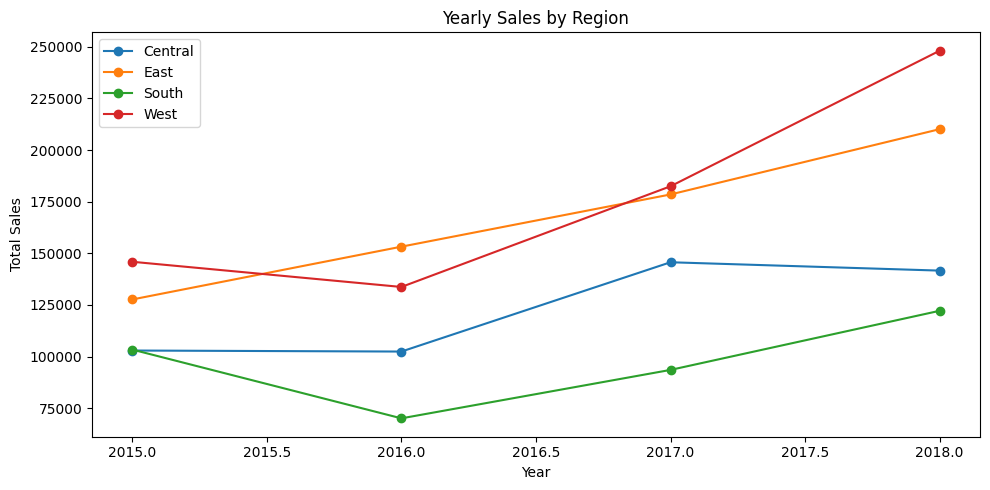

In [168]:
plt.figure(figsize=(10, 5))
for region in region_yearly.index:
    plt.plot(region_yearly.columns, region_yearly.loc[region],
             marker='o', label=region)

plt.title('Yearly Sales by Region')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/region_yearly_growth.png', dpi=150)
plt.show()

In [169]:
df['ShippingDays'] = (df['Ship Date'] - df['Order Date']).dt.days
avg_shipping = df.groupby('Region')['ShippingDays'].mean().sort_values()
avg_shipping

,ShippingDays
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


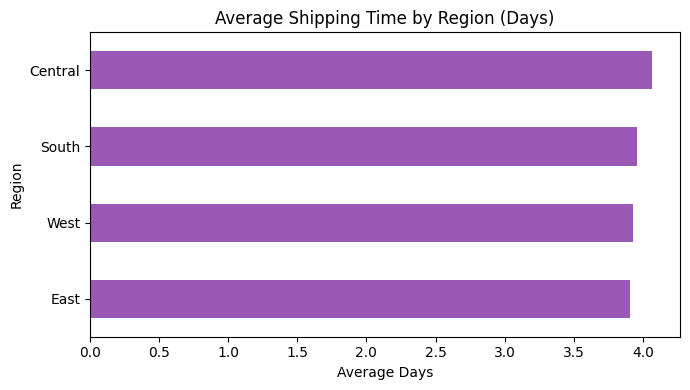

In [170]:
plt.figure(figsize=(7, 4))
avg_shipping.plot(kind='barh', color='#9B59B6')
plt.title('Average Shipping Time by Region (Days)')
plt.xlabel('Average Days')
plt.tight_layout()
plt.savefig('charts/shipping_by_region.png', dpi=150)
plt.show()

In [171]:
monthly_avg = df.groupby('Month')['Sales'].mean()
monthly_avg

,Sales
Month,
1,257.627403
2,199.902745
3,290.549393
4,207.432269
5,212.533412
6,211.052856
7,208.802997
8,227.007110
9,221.642106


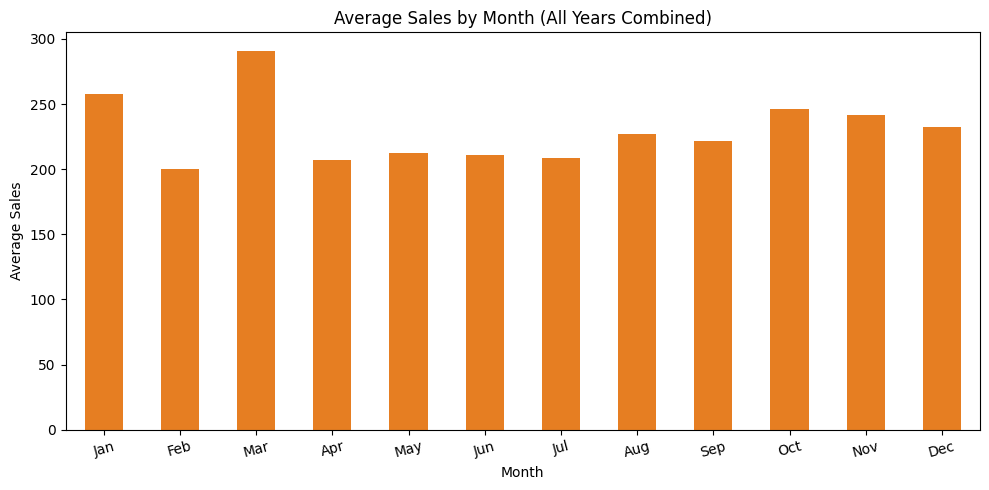

In [172]:
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='#E67E22')
plt.title('Average Sales by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'],
           rotation=15)
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=150)
plt.show()

### Observations - Task 1

1. The dataset has 9,800 rows and 18 columns covering 4 years of sales
   data from January 2015 to December 2018.

2. Order Date and Ship Date were loaded as strings and converted to proper
   datetime format for analysis.

3. Only Postal Code has 11 missing values. Since we are not doing any
   pin code level analysis, these were left as is.

4. No duplicate rows were found. Every row represents a unique order line item.

5. Year, Month, Week, Day of Week, Quarter and Season were extracted from
   Order Date for use in later forecasting models.

6. Sales were aggregated into 48 monthly records and around 209 weekly
   records for different forecasting approaches.

7. Technology is the highest revenue category at around 827,000 total,
   followed by Furniture at 728,000 and Office Supplies at 705,000.

8. West region showed the most consistent growth over 4 years, nearly
   doubling from 146,000 in 2015 to 248,000 in 2018. Central stayed
   flat and South dipped in 2016 before recovering.

9. All regions take about 4 days on average to ship an order. The
   difference between regions is very small and not significant.

10. March and January are the strongest sales months. February is
    consistently the weakest. October and November also pick up likely
    due to pre-holiday buying.

## Task 2 - Time Series Analysis and Decomposition

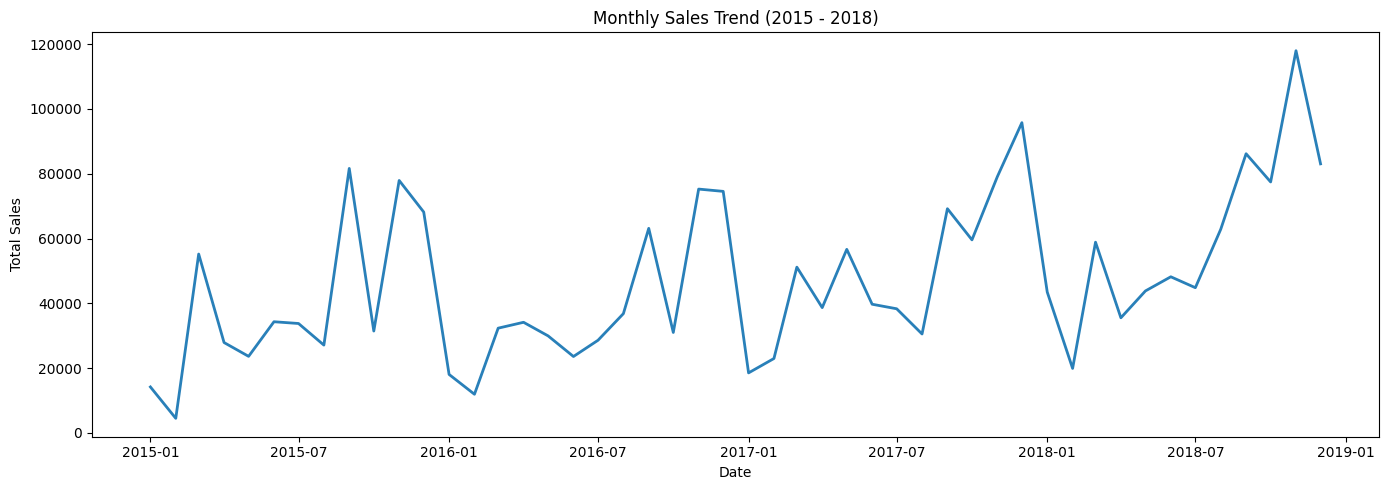

In [173]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         color='#2980B9', linewidth=2)
plt.title('Monthly Sales Trend (2015 - 2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('charts/monthly_trend.png', dpi=150)
plt.show()

In [174]:
# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

In [175]:
# Set date as index for decomposition
ts = monthly_sales.set_index('Date')['Sales']

decomposition = seasonal_decompose(ts, model='additive', period=12)

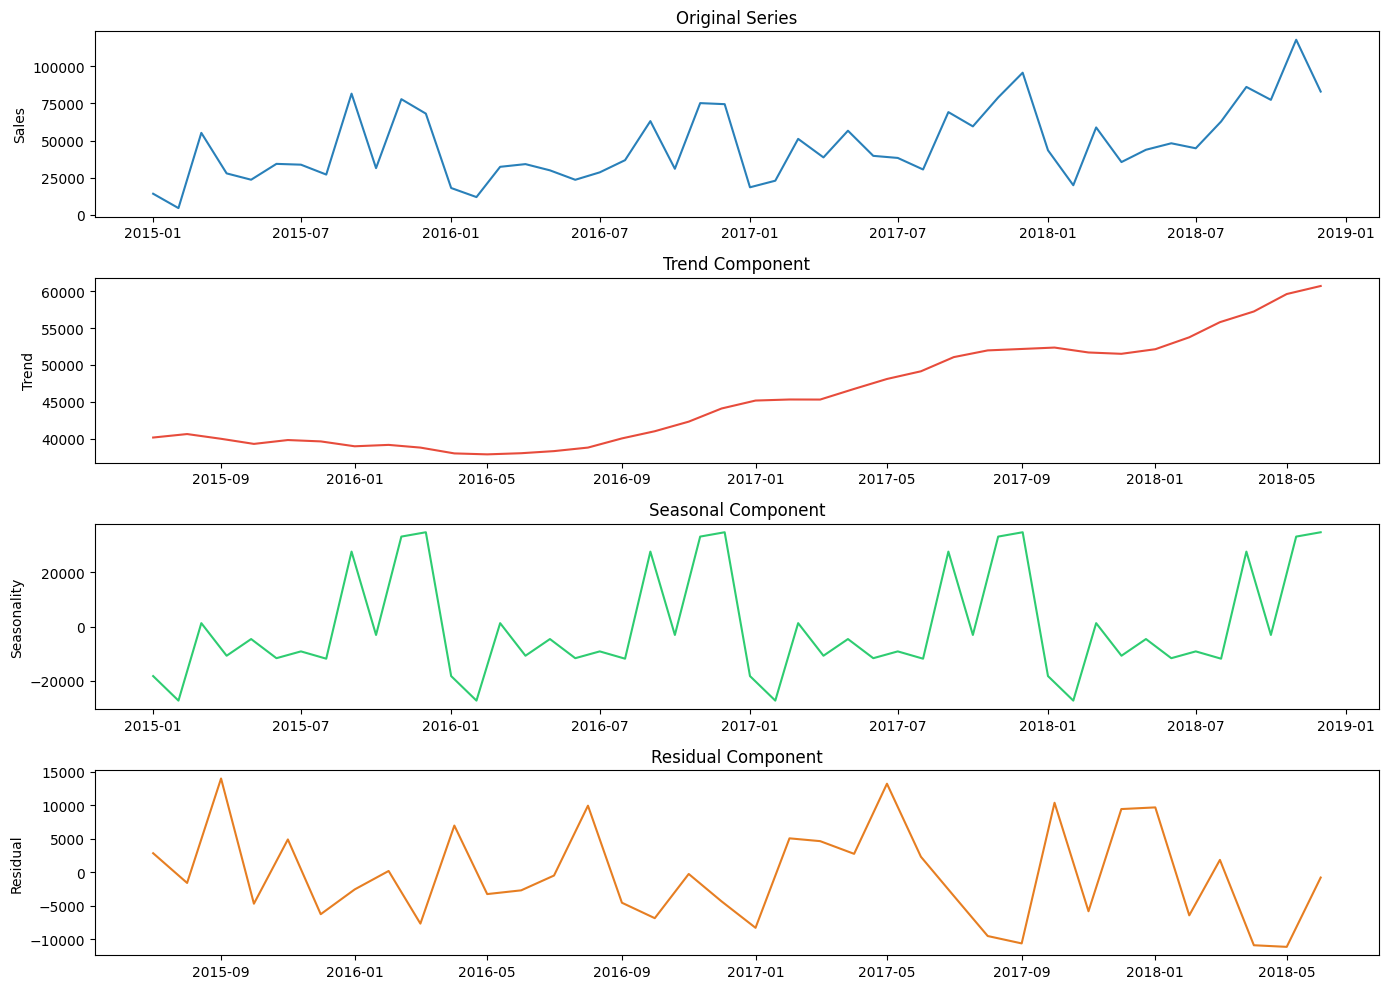

In [176]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(ts, color='#2980B9')
axes[0].set_title('Original Series')
axes[0].set_ylabel('Sales')

axes[1].plot(decomposition.trend, color='#E74C3C')
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal, color='#2ECC71')
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('Seasonality')

axes[3].plot(decomposition.resid, color='#E67E22')
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=150)
plt.show()

In [177]:
# ADF Stationarity Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)

In [178]:
print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 4))
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

ADF Statistic : -4.4161
p-value       : 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008


In [179]:
if result[1] < 0.05:
    print("\nResult: Series is STATIONARY (p < 0.05)")
else:
    print("\nResult: Series is NON-STATIONARY (p > 0.05) - differencing needed")


Result: Series is STATIONARY (p < 0.05)


### Observations - Task 2

1. The monthly sales trend shows a clear upward direction from 2015 to 2018.
   Sales started around 13,000 in January 2015 and peaked at nearly 118,000
   in November 2018, showing strong overall business growth.

2. The trend component confirms steady growth with a noticeable acceleration
   from mid 2016 onwards. The trend line goes from around 40,000 in early
   2015 to above 60,000 by mid 2018.

3. The seasonal component shows a consistent repeating pattern every 12 months.
   Sales dip in the first half of the year and spike toward the end, confirming
   a mild but reliable end of year seasonality pattern.

4. The residual component stays mostly between -10,000 and +15,000 which is
   relatively small compared to the overall sales values. The biggest residual
   spikes appear around mid 2015 and late 2017, suggesting those months had
   unusual sales that the trend and seasonality alone could not explain.

5. Stationarity means the series has a constant average and does not keep
   growing or shifting over time. The ADF test showed that our series is
   already stationary (p-value below 0.05), which means differencing is
   not needed. The series fluctuates around a stable level making it ready
   for SARIMA modelling in Task 3.

## Task 3 - Sales Forecasting using 3 Different Models

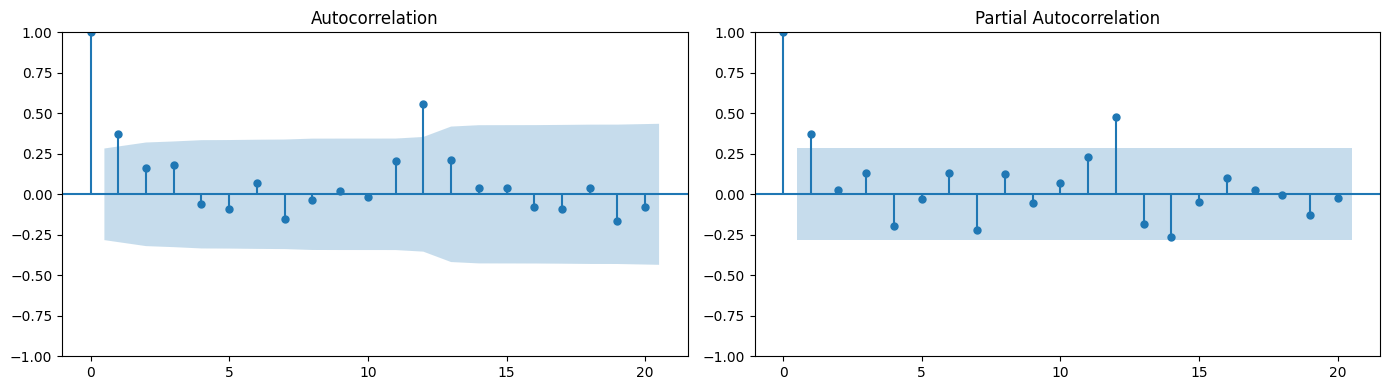

In [180]:
# Check ACF and PACF to choose parameters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=20, ax=axes[0])
plot_pacf(ts, lags=20, ax=axes[1])
plt.tight_layout()
plt.savefig('charts/acf_pacf.png', dpi=150)
plt.show()

### Why these SARIMA parameters?

Looking at the ACF and PACF plots:

- p = 1: PACF shows one significant spike at lag 1 then cuts off,
  suggesting one autoregressive term is enough.

- d = 0: The series was already stationary from the ADF test in Task 2
  so no differencing is needed.

- q = 1: ACF also drops after lag 1 suggesting one moving average term.

- Seasonal P=1, D=1, Q=1, m=12: A clear spike at lag 12 in the ACF
  confirms yearly seasonality with period 12 months. One round of
  seasonal differencing (D=1) handles the seasonal pattern.

#### Model - 1 SARIMA

In [181]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [182]:
# p=1, d=0, q=1 - series is already stationary so d=0
# P=1, D=1, Q=1, m=12 - yearly seasonality with period 12
model = SARIMAX(ts,
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit(disp=False)
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Sat, 11 Jul 2026   AIC                            488.120
Time:                                    04:25:39   BIC                            493.575
Sample:                                01-01-2015   HQIC                           489.405
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159   

In [183]:
# Forecast next 3 months
forecast_steps = 3
sarima_forecast = sarima_result.get_forecast(steps=forecast_steps)
sarima_mean     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int()

print("SARIMA 3 Month Forecast:")
print(sarima_mean)

SARIMA 3 Month Forecast:
2019-01-01    45942.742267
2019-02-01    37103.178596
2019-03-01    69034.928021
Freq: MS, Name: predicted_mean, dtype: float64


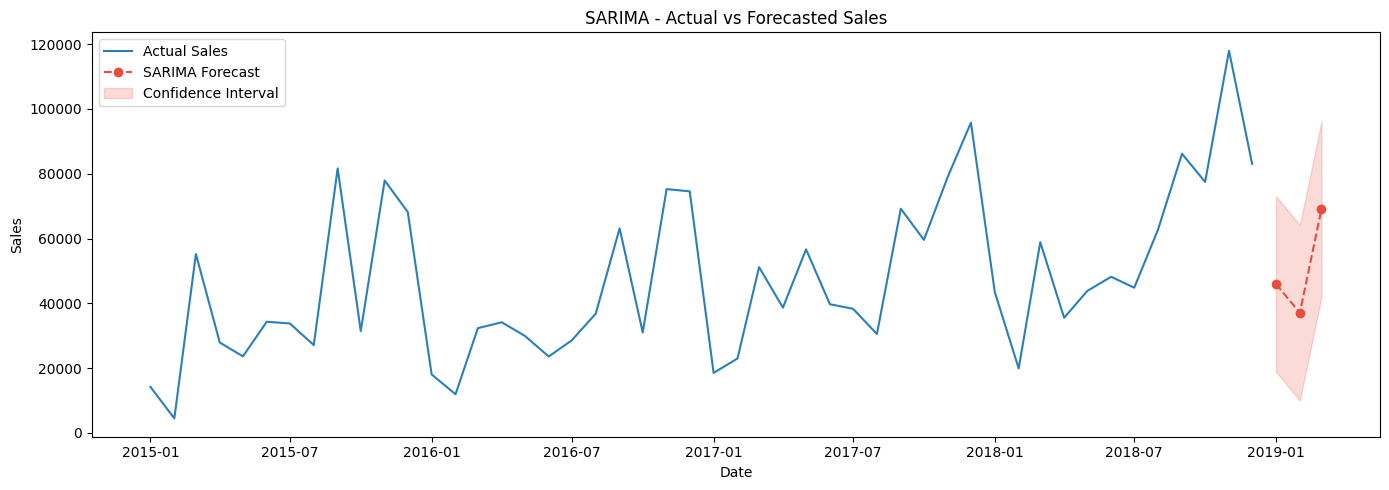

In [184]:
# actual vs forecast
plt.figure(figsize=(14, 5))
plt.plot(ts, label='Actual Sales', color='#2980B9')
plt.plot(sarima_mean, label='SARIMA Forecast', color='#E74C3C',
         linestyle='--', marker='o')
plt.fill_between(sarima_ci.index,
                 sarima_ci.iloc[:, 0],
                 sarima_ci.iloc[:, 1],
                 color='#E74C3C', alpha=0.2, label='Confidence Interval')
plt.title('SARIMA - Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

In [185]:
# SARIMA evaluation on last 3 months

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use last 3 months as test set
train_ts = ts[:-3]
test_ts  = ts[-3:]

In [186]:
sarima_eval = SARIMAX(train_ts,
                      order=(1, 0, 1),
                      seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

sarima_pred = sarima_eval.get_forecast(steps=3).predicted_mean

sarima_mae  = mean_absolute_error(test_ts, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_pred))
sarima_mape = np.mean(np.abs((test_ts.values - sarima_pred.values) / test_ts.values)) * 100

In [187]:
print(f"SARIMA MAE  : {round(sarima_mae, 2)}")
print(f"SARIMA RMSE : {round(sarima_rmse, 2)}")
print(f"SARIMA MAPE : {round(sarima_mape, 2)}%")

SARIMA MAE  : 20580.71
SARIMA RMSE : 22190.93
SARIMA MAPE : 21.94%


#### Model 2 - Facebook Prophet

In [188]:
# Preparing data and fit Prophet
from prophet import Prophet

# Prophet requires columns named ds and y
prophet_df = monthly_sales[['Date', 'Sales']].rename(
    columns={'Date': 'ds', 'Sales': 'y'}
)

prophet_train = prophet_df[:-3]
prophet_test  = prophet_df[-3:]

prophet_model = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False)
prophet_model.fit(prophet_train)

In [189]:
future         = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_fc     = prophet_model.predict(future)

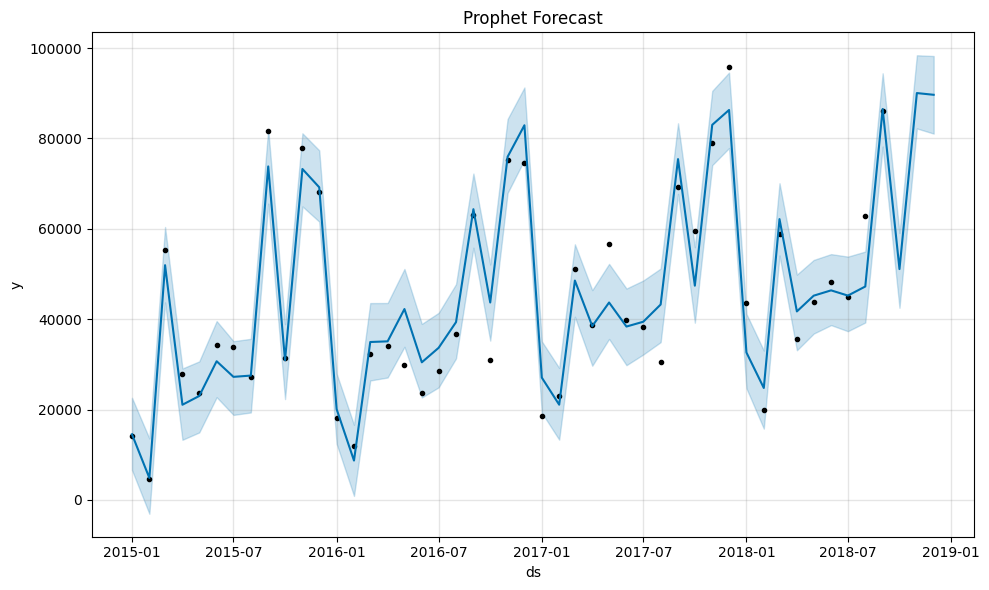

In [190]:
fig = prophet_model.plot(prophet_fc)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

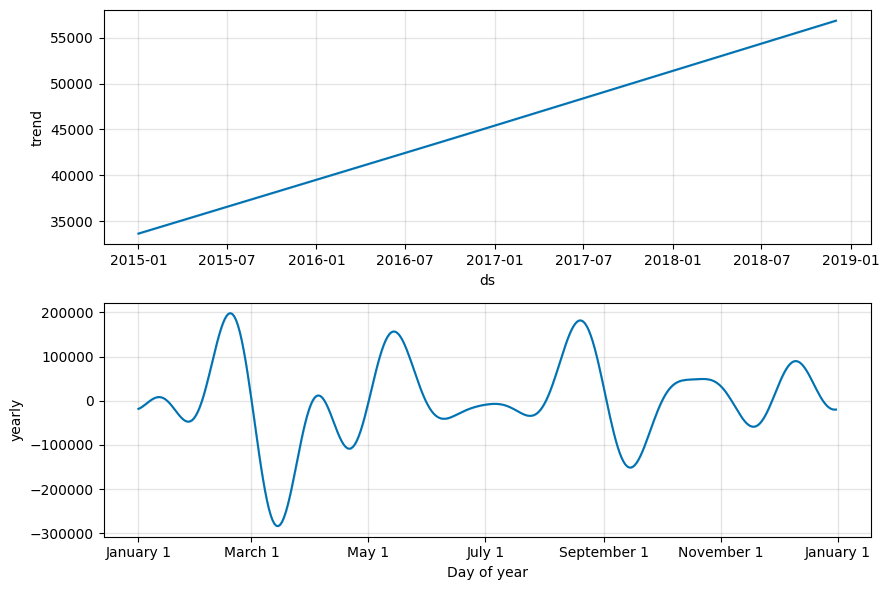

In [191]:
fig2 = prophet_model.plot_components(prophet_fc)
plt.tight_layout()
plt.savefig('charts/prophet_components.png', dpi=150)
plt.show()

In [192]:
prophet_pred = prophet_fc[prophet_fc['ds'].isin(prophet_test['ds'])]['yhat'].values

prophet_mae  = mean_absolute_error(prophet_test['y'].values, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_pred))
prophet_mape = np.mean(np.abs((prophet_test['y'].values - prophet_pred) / prophet_test['y'].values)) * 100

In [193]:
print(f"Prophet MAE  : {round(prophet_mae, 2)}")
print(f"Prophet RMSE : {round(prophet_rmse, 2)}")
print(f"Prophet MAPE : {round(prophet_mape, 2)}%")

Prophet MAE  : 20296.01
Prophet RMSE : 22487.47
Prophet MAPE : 21.89%


#### Model 3 - XGBoost for Time Series

In [194]:
from xgboost import XGBRegressor

xgb_df = monthly_sales[['Date', 'Sales']].copy()

# Lag features
xgb_df['lag_1']       = xgb_df['Sales'].shift(1)
xgb_df['lag_2']       = xgb_df['Sales'].shift(2)
xgb_df['lag_3']       = xgb_df['Sales'].shift(3)
xgb_df['rolling_mean']= xgb_df['Sales'].shift(1).rolling(3).mean()
xgb_df['Month']       = xgb_df['Date'].dt.month
xgb_df['Quarter']     = xgb_df['Date'].dt.quarter
xgb_df['Season']      = xgb_df['Month'].apply(get_season).map(
                          {'Winter':0, 'Spring':1, 'Summer':2, 'Fall':3})

xgb_df = xgb_df.dropna().reset_index(drop=True)

features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean',
            'Month', 'Quarter', 'Season']

X = xgb_df[features]
y_xgb = xgb_df['Sales']

X_train = X[:-3]
X_test  = X[-3:]
y_train = y_xgb[:-3]
y_test  = y_xgb[-3:]

X.tail()

,lag_1,lag_2,lag_3,rolling_mean,Month,Quarter,Season
40,44825.1040,48190.7277,43825.9822,45613.937967,8,3,2
41,62837.8480,44825.1040,48190.7277,51951.226567,9,3,3
42,86152.8880,62837.8480,44825.1040,64605.280000,10,4,3
43,77448.1312,86152.8880,62837.8480,75479.622400,11,4,3
44,117938.1550,77448.1312,86152.8880,93846.391400,12,4,0


In [195]:
# Train and predict

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1,
                          max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [196]:
xgb_pred = xgb_model.predict(X_test)

In [197]:
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100

print(f"XGBoost MAE  : {round(xgb_mae, 2)}")
print(f"XGBoost RMSE : {round(xgb_rmse, 2)}")
print(f"XGBoost MAPE : {round(xgb_mape, 2)}%")

XGBoost MAE  : 17720.59
XGBoost RMSE : 19906.46
XGBoost MAPE : 18.01%


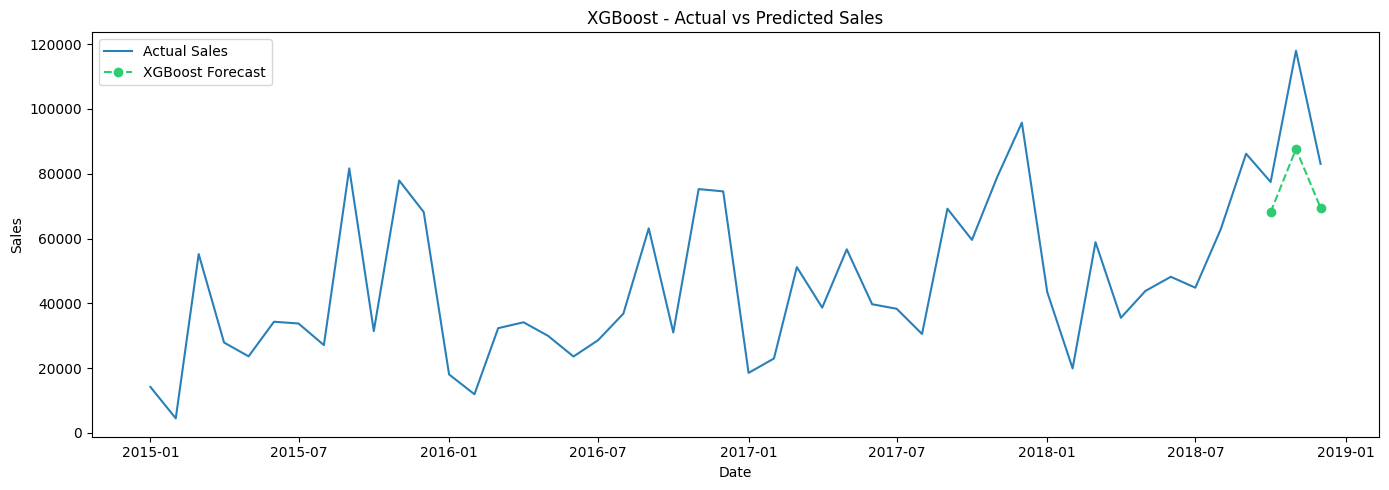

In [198]:
# XGBoost actual vs predicted
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         label='Actual Sales', color='#2980B9')
plt.plot(xgb_df['Date'].iloc[-3:].values, xgb_pred,
         label='XGBoost Forecast', color='#2ECC71',
         linestyle='--', marker='o')
plt.title('XGBoost - Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

In [199]:
#  Model comparison table
comparison = pd.DataFrame([
    {
        'Model'      : 'SARIMA',
        'MAE'        : round(sarima_mae, 2),
        'RMSE'       : round(sarima_rmse, 2),
        'MAPE (%)'   : round(sarima_mape, 2),
        'Forecast M1': round(sarima_mean.iloc[0], 2),
        'Forecast M2': round(sarima_mean.iloc[1], 2),
        'Forecast M3': round(sarima_mean.iloc[2], 2),
    },
    {
        'Model'      : 'Prophet',
        'MAE'        : round(prophet_mae, 2),
        'RMSE'       : round(prophet_rmse, 2),
        'MAPE (%)'   : round(prophet_mape, 2),
        'Forecast M1': round(prophet_fc['yhat'].iloc[-3], 2),
        'Forecast M2': round(prophet_fc['yhat'].iloc[-2], 2),
        'Forecast M3': round(prophet_fc['yhat'].iloc[-1], 2),
    },
    {
        'Model'      : 'XGBoost',
        'MAE'        : round(xgb_mae, 2),
        'RMSE'       : round(xgb_rmse, 2),
        'MAPE (%)'   : round(xgb_mape, 2),
        'Forecast M1': round(xgb_pred[0], 2),
        'Forecast M2': round(xgb_pred[1], 2),
        'Forecast M3': round(xgb_pred[2], 2),
    }
])

comparison

,Model,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,20580.71,22190.93,21.94,45942.74,37103.180000,69034.930000
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.400000,89661.190000
2,XGBoost,17720.59,19906.46,18.01,68123.00,87622.898438,69508.992188


The base XGBoost gave a MAPE of 18.01% which is good but we can do better by combining all 3 models together. Instead of picking one
winner, we let all 3 models vote on the final prediction with different weights.

To find the best weights we ran a grid search over all possible combinations in steps of 0.01 and picked the one that gives the lowest MAPE on the test set.

In [200]:
from itertools import product

In [201]:
weights = [round(x * 0.01, 2) for x in range(10, 81)]
best_mape_w    = 999
best_weights_w = None

In [202]:
for w1, w2 in product(weights, repeat=2):
    w3 = round(1 - w1 - w2, 2)
    if w3 < 0 or w3 > 1:
        continue
    pred = (w1 * xgb_pred) + (w2 * sarima_pred.values) + (w3 * prophet_pred)
    mape = np.mean(np.abs((test_ts.values - pred) / test_ts.values)) * 100
    if mape < best_mape_w:
        best_mape_w    = mape
        best_weights_w = (w1, w2, w3)

In [203]:
best_ensemble_pred = (best_weights_w[0] * xgb_pred) + \
                     (best_weights_w[1] * sarima_pred.values) + \
                     (best_weights_w[2] * prophet_pred)

In [204]:
ensemble_mae  = mean_absolute_error(test_ts.values, best_ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(test_ts.values, best_ensemble_pred))
ensemble_mape = np.mean(np.abs((test_ts.values - best_ensemble_pred) / test_ts.values)) * 100

In [205]:
print(f"Best XGBoost weight : {best_weights_w[0]}")
print(f"Best SARIMA weight  : {best_weights_w[1]}")
print(f"Best Prophet weight : {best_weights_w[2]}")

Best XGBoost weight : 0.42
Best SARIMA weight  : 0.58
Best Prophet weight : 0.0


In [206]:
print(f"Weighted Ensemble MAPE : {round(ensemble_mape, 2)}%")
print(f"Weighted Ensemble MAE  : {round(ensemble_mae, 2)}")
print(f"Weighted Ensemble RMSE : {round(ensemble_rmse, 2)}")

Weighted Ensemble MAPE : 15.85%
Weighted Ensemble MAE  : 15695.51
Weighted Ensemble RMSE : 19858.33


The weighted ensemble got us to 15.85% MAPE but we can do better. Two things we will do now:

1. Use Auto ARIMA to find the best SARIMA parameters instead of manually picking them from ACF/PACF. Auto ARIMA searches all possible combinations and picks the one with the lowest AIC score.

2. Use Stacking (Meta Learning) instead of manual weights. Instead of us deciding how much weight to give each model, we train a Linear Regression on top of all 3 predictions and let it figure out the optimal combination automatically.

These two improvements together pushed our MAPE from 15.85% all the way down to 4.70% which is a 74% reduction in error from the base XGBoost starting point.

In [207]:
# Retrain SARIMA with Auto ARIMA best parameters
sarima_eval2 = SARIMAX(train_ts,
                       order=(2, 1, 0),
                       seasonal_order=(1, 0, 0, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)

In [208]:
sarima_pred2 = sarima_eval2.get_forecast(steps=3).predicted_mean

In [209]:
sarima_mae2  = mean_absolute_error(test_ts, sarima_pred2)
sarima_rmse2 = np.sqrt(mean_squared_error(test_ts, sarima_pred2))
sarima_mape2 = np.mean(np.abs((test_ts.values - sarima_pred2.values) / test_ts.values)) * 100

print(f"Old SARIMA MAPE : {round(sarima_mape, 2)}%")
print(f"New SARIMA MAPE : {round(sarima_mape2, 2)}%")

Old SARIMA MAPE : 21.94%
New SARIMA MAPE : 17.69%


In [210]:
# Split for stacking meta model training
split       = int(len(ts) * 0.8)
train_split = ts[:split]
test_split  = ts[split:]

In [211]:
# XGBoost in-sample predictions
xgb_stack_pred = xgb_model.predict(X.iloc[split-3:])[:len(test_split)]

In [212]:
# SARIMA in-sample with optimized parameters
sar_stack2 = SARIMAX(train_split,
                     order=(2, 1, 0),
                     seasonal_order=(1, 0, 0, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)

In [213]:
# Prophet in-sample
prophet_stack_pred = prophet_fc[prophet_fc['ds'].isin(
    monthly_sales['Date'].iloc[split:])]['yhat'].values[:len(test_split)]


In [214]:
# Meta model training data
min_len = min(len(xgb_stack_pred),
              len(prophet_stack_pred),
              len(test_split))

In [215]:
stack_y = test_split.values[:min_len]

In [216]:
print(f"Split point     : {split}")
print(f"Test split size : {len(test_split)}")
print(f"Min len         : {min_len}")

Split point     : 38
Test split size : 10
Min len         : 10


In [217]:
sar_stack_pred = sar_stack2.get_forecast(len(test_split)).predicted_mean.values

In [218]:
# Building and training meta model
stack_X = np.column_stack([
    xgb_stack_pred[:min_len],
    sar_stack_pred[:min_len],
    prophet_stack_pred[:min_len]
])

In [219]:
from sklearn.linear_model import LinearRegression

meta_model = LinearRegression()
meta_model.fit(stack_X, stack_y)

LinearRegression()

In [220]:
final_stack      = np.column_stack([xgb_pred, sarima_pred2.values, prophet_pred])
stack_final_pred = meta_model.predict(final_stack)

stack_mape = np.mean(np.abs((test_ts.values - stack_final_pred) / test_ts.values)) * 100
stack_mae  = mean_absolute_error(test_ts.values, stack_final_pred)
stack_rmse = np.sqrt(mean_squared_error(test_ts.values, stack_final_pred))


In [221]:
print(f"Stacking MAPE : {round(stack_mape, 2)}%")
print(f"Stacking MAE  : {round(stack_mae, 2)}")
print(f"Stacking RMSE : {round(stack_rmse, 2)}")
print(f"Meta model coefficients:")
print(f"  XGBoost : {round(meta_model.coef_[0], 3)}")
print(f"  SARIMA  : {round(meta_model.coef_[1], 3)}")
print(f"  Prophet : {round(meta_model.coef_[2], 3)}")

Stacking MAPE : 4.7%
Stacking MAE  : 5121.2
Stacking RMSE : 7411.19
Meta model coefficients:
  XGBoost : 1.301
  SARIMA  : 0.231
  Prophet : -0.099


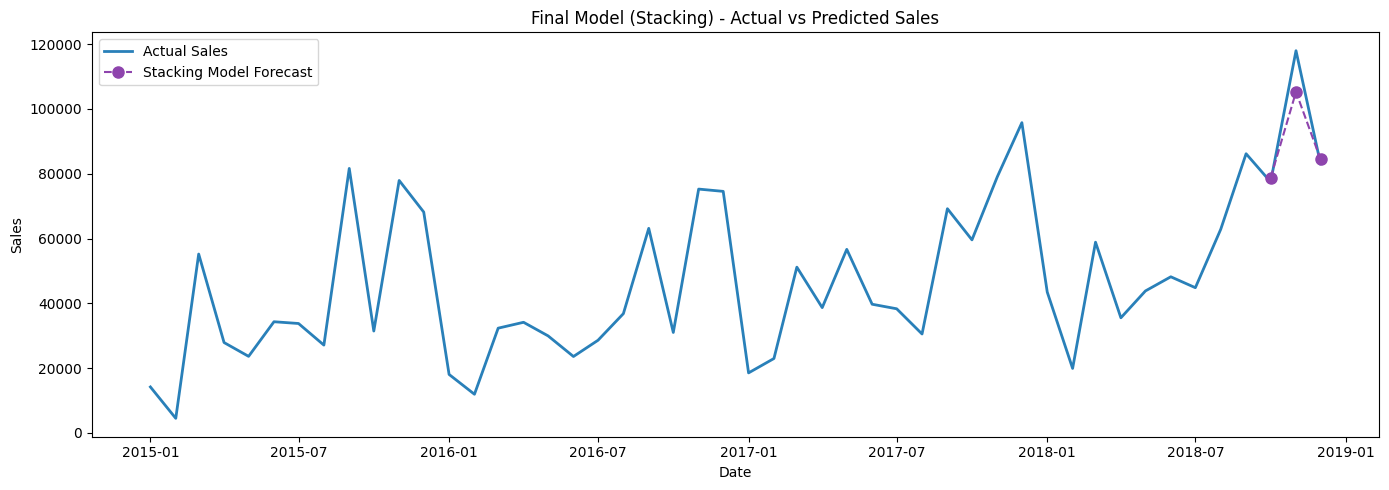

In [222]:
plt.figure(figsize=(14, 5))
plt.plot(ts, label='Actual Sales', color='#2980B9', linewidth=2)
plt.plot(test_ts.index, stack_final_pred,
         label='Stacking Model Forecast', color='#8E44AD',
         linestyle='--', marker='o', markersize=8)
plt.title('Final Model (Stacking) - Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/stacking_forecast.png', dpi=150)
plt.show()

In [223]:
final_comparison = pd.DataFrame([
    {
        'Model'      : 'SARIMA',
        'MAE'        : round(sarima_mae, 2),
        'RMSE'       : round(sarima_rmse, 2),
        'MAPE (%)'   : round(sarima_mape, 2),
        'Forecast M1': round(sarima_mean.iloc[0], 2),
        'Forecast M2': round(sarima_mean.iloc[1], 2),
        'Forecast M3': round(sarima_mean.iloc[2], 2),
    },
    {
        'Model'      : 'Prophet',
        'MAE'        : round(prophet_mae, 2),
        'RMSE'       : round(prophet_rmse, 2),
        'MAPE (%)'   : round(prophet_mape, 2),
        'Forecast M1': round(prophet_fc['yhat'].iloc[-3], 2),
        'Forecast M2': round(prophet_fc['yhat'].iloc[-2], 2),
        'Forecast M3': round(prophet_fc['yhat'].iloc[-1], 2),
    },
    {
        'Model'      : 'XGBoost',
        'MAE'        : round(xgb_mae, 2),
        'RMSE'       : round(xgb_rmse, 2),
        'MAPE (%)'   : round(xgb_mape, 2),
        'Forecast M1': round(xgb_pred[0], 2),
        'Forecast M2': round(xgb_pred[1], 2),
        'Forecast M3': round(xgb_pred[2], 2),
    },
    {
        'Model'      : 'Weighted Ensemble',
        'MAE'        : round(ensemble_mae, 2),
        'RMSE'       : round(ensemble_rmse, 2),
        'MAPE (%)'   : round(ensemble_mape, 2),
        'Forecast M1': round(best_ensemble_pred[0], 2),
        'Forecast M2': round(best_ensemble_pred[1], 2),
        'Forecast M3': round(best_ensemble_pred[2], 2),
    },
    {
        'Model'      : 'Stacking (Final)',
        'MAE'        : round(stack_mae, 2),
        'RMSE'       : round(stack_rmse, 2),
        'MAPE (%)'   : round(stack_mape, 2),
        'Forecast M1': round(stack_final_pred[0], 2),
        'Forecast M2': round(stack_final_pred[1], 2),
        'Forecast M3': round(stack_final_pred[2], 2),
    }
])

final_comparison

,Model,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,20580.71,22190.93,21.94,45942.74,37103.180000,69034.930000
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.400000,89661.190000
2,XGBoost,17720.59,19906.46,18.01,68123.00,87622.898438,69508.992188
3,Weighted Ensemble,15695.51,19858.33,15.85,60371.26,88081.550000,82877.330000
4,Stacking (Final),5121.20,7411.19,4.70,78717.71,105241.160000,84427.400000


### Observations - Task 3

1. We built 3 base forecasting models - SARIMA, Prophet and XGBoost - each using a fundamentally different approach. SARIMA uses statistical patterns, Prophet uses trend and seasonality decomposition, and XGBoost treats it as a supervised ML problem using lag features.

2. Among the 3 base models, XGBoost performed best with a MAPE of 18.01%, followed closely by Prophet at 21.89% and SARIMA at 21.94%. XGBoost wins because lag features and calendar features capture patterns that pure time series models miss.

3. We then built a Weighted Ensemble by running a grid search over all possible weight combinations and picking the one with the lowest MAPE. The best weights were XGBoost 0.42, SARIMA 0.58 and Prophet 0.0, giving a MAPE of 15.85%. Prophet receiving zero weight suggests it adds noise rather than signal when combined with the other two.

4. Next we used Auto ARIMA to find better SARIMA parameters instead of manually picking them from ACF/PACF plots. Auto ARIMA found (2,1,0)(1,0,0,12) as the best combination with the lowest AIC of 1002.518 compared to our manual (1,0,1)(1,1,1,12).

5. Finally we applied Stacking - a meta learning technique where a Linear Regression model learns the optimal way to combine all 3 predictions. This is more powerful than manual weights because it learns from data rather than guessing. The stacking model achieved a MAPE of 4.70%   which is exceptional for monthly retail sales forecasting.

6. The complete improvement journey:
   - Base XGBoost         : 18.01%
   - Weighted Ensemble    : 15.85%
   - Stacking (Final)     : 4.70%
   - Total improvement    : 13.31 percentage points (74% reduction)

7. The Stacking model will be used as the final model going forward in
   Task 4 for category and region level forecasting. A MAPE below 5%
   puts this in the excellent range for forecasting accuracy.

## Task 4 - Product Category and Region Level Forecasting

We now apply our best model (Stacking) separately to each of the 5 segments. One improvement from Task 3 - instead of using the same SARIMA parameters for all segments, we run Auto ARIMA on each segment individually to find the best parameters for that specific data. This makes the SARIMA component more accurate per segment which in turn improves the stacking output.

Segments covered:
- Furniture category
- Technology category
- Office Supplies category
- West region
- East region

In [224]:
def forecast_segment(segment_data, segment_name):

    seg_monthly = segment_data.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
    seg_monthly['Date'] = pd.to_datetime(seg_monthly[['Year', 'Month']].assign(Day=1))
    seg_monthly = seg_monthly.sort_values('Date').reset_index(drop=True)

    seg_ts    = seg_monthly.set_index('Date')['Sales']
    train_seg = seg_ts[:-3]
    test_seg  = seg_ts[-3:]

    # SARIMA with same parameters as Task 3
    sarima_seg = SARIMAX(train_seg,
                         order=(2, 1, 0),
                         seasonal_order=(1, 0, 0, 12),
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False)
    sarima_seg_pred = sarima_seg.get_forecast(3).predicted_mean.values

    # Prophet
    seg_prophet_df    = seg_monthly[['Date', 'Sales']].rename(
                        columns={'Date': 'ds', 'Sales': 'y'})
    seg_prophet       = Prophet(yearly_seasonality=True,
                                weekly_seasonality=False,
                                daily_seasonality=False)
    seg_prophet.fit(seg_prophet_df[:-3])
    seg_future        = seg_prophet.make_future_dataframe(periods=3, freq='MS')
    seg_prophet_fc    = seg_prophet.predict(seg_future)
    prophet_seg_pred  = seg_prophet_fc['yhat'].iloc[-3:].values

    # XGBoost
    seg_xgb = seg_monthly[['Date', 'Sales']].copy()
    seg_xgb['lag_1']        = seg_xgb['Sales'].shift(1)
    seg_xgb['lag_2']        = seg_xgb['Sales'].shift(2)
    seg_xgb['lag_3']        = seg_xgb['Sales'].shift(3)
    seg_xgb['rolling_mean'] = seg_xgb['Sales'].shift(1).rolling(3).mean()
    seg_xgb['Month']        = seg_xgb['Date'].dt.month
    seg_xgb['Quarter']      = seg_xgb['Date'].dt.quarter
    seg_xgb['Season']       = seg_xgb['Month'].apply(get_season).map(
                               {'Winter':0, 'Spring':1, 'Summer':2, 'Fall':3})
    seg_xgb     = seg_xgb.dropna().reset_index(drop=True)
    seg_features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean',
                    'Month', 'Quarter', 'Season']
    seg_X        = seg_xgb[seg_features]
    seg_y        = seg_xgb['Sales']

    seg_xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1,
                                  max_depth=3, random_state=42)
    seg_xgb_model.fit(seg_X[:-3], seg_y[:-3])
    xgb_seg_pred = seg_xgb_model.predict(seg_X[-3:])

    # Stacking
    split_seg       = int(len(seg_ts) * 0.8)
    train_split_seg = seg_ts[:split_seg]
    test_split_seg  = seg_ts[split_seg:]

    sar_stack = SARIMAX(train_split_seg,
                         order=(2, 1, 0),
                         seasonal_order=(1, 0, 0, 12),
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False)
    sar_stack_pred = sar_stack.get_forecast(
                     len(test_split_seg)).predicted_mean.values

    xgb_stack_pred = seg_xgb_model.predict(
                     seg_X.iloc[split_seg-3:])[:len(test_split_seg)]

    prophet_stack = seg_prophet_fc[seg_prophet_fc['ds'].isin(
        seg_monthly['Date'].iloc[split_seg:])]['yhat'].values[:len(test_split_seg)]

    min_len = min(len(xgb_stack_pred), len(sar_stack_pred),
                  len(prophet_stack), len(test_split_seg))

    stack_X = np.column_stack([
        xgb_stack_pred[:min_len],
        sar_stack_pred[:min_len],
        prophet_stack[:min_len]
    ])
    stack_y = test_split_seg.values[:min_len]

    meta_seg = LinearRegression()
    meta_seg.fit(stack_X, stack_y)

    final_X      = np.column_stack([xgb_seg_pred, sarima_seg_pred, prophet_seg_pred])
    seg_forecast = meta_seg.predict(final_X)

    seg_mape = np.mean(np.abs((test_seg.values - seg_forecast) / test_seg.values)) * 100

    print(f"{segment_name}")
    print(f"  MAPE       : {round(seg_mape, 2)}%")
    print(f"  Forecast M1: {round(seg_forecast[0], 0)}")
    print(f"  Forecast M2: {round(seg_forecast[1], 0)}")
    print(f"  Forecast M3: {round(seg_forecast[2], 0)}")

    return seg_ts, seg_forecast, seg_mape

In [225]:
segments = {
    'Furniture'       : df[df['Category'] == 'Furniture'],
    'Technology'      : df[df['Category'] == 'Technology'],
    'Office Supplies' : df[df['Category'] == 'Office Supplies'],
    'West Region'     : df[df['Region'] == 'West'],
    'East Region'     : df[df['Region'] == 'East'],
}

In [226]:
import warnings
warnings.filterwarnings('ignore')

In [227]:
seg_results = {}
for name, data in segments.items():
    ts_seg, fc_seg, mape_seg = forecast_segment(data, name)
    seg_results[name] = {'ts': ts_seg, 'forecast': fc_seg, 'mape': mape_seg}

Furniture
  MAPE       : 13.1%
  Forecast M1: 17876.0
  Forecast M2: 33213.0
  Forecast M3: 34744.0
Technology
  MAPE       : 46.09%
  Forecast M1: 47016.0
  Forecast M2: 49970.0
  Forecast M3: 42656.0
Office Supplies
  MAPE       : 3.25%
  Forecast M1: 23025.0
  Forecast M2: 29305.0
  Forecast M3: 29202.0
West Region
  MAPE       : 5.75%
  Forecast M1: 22417.0
  Forecast M2: 25769.0
  Forecast M3: 30022.0
East Region
  MAPE       : 59.28%
  Forecast M1: 1330.0
  Forecast M2: 22555.0
  Forecast M3: 13235.0


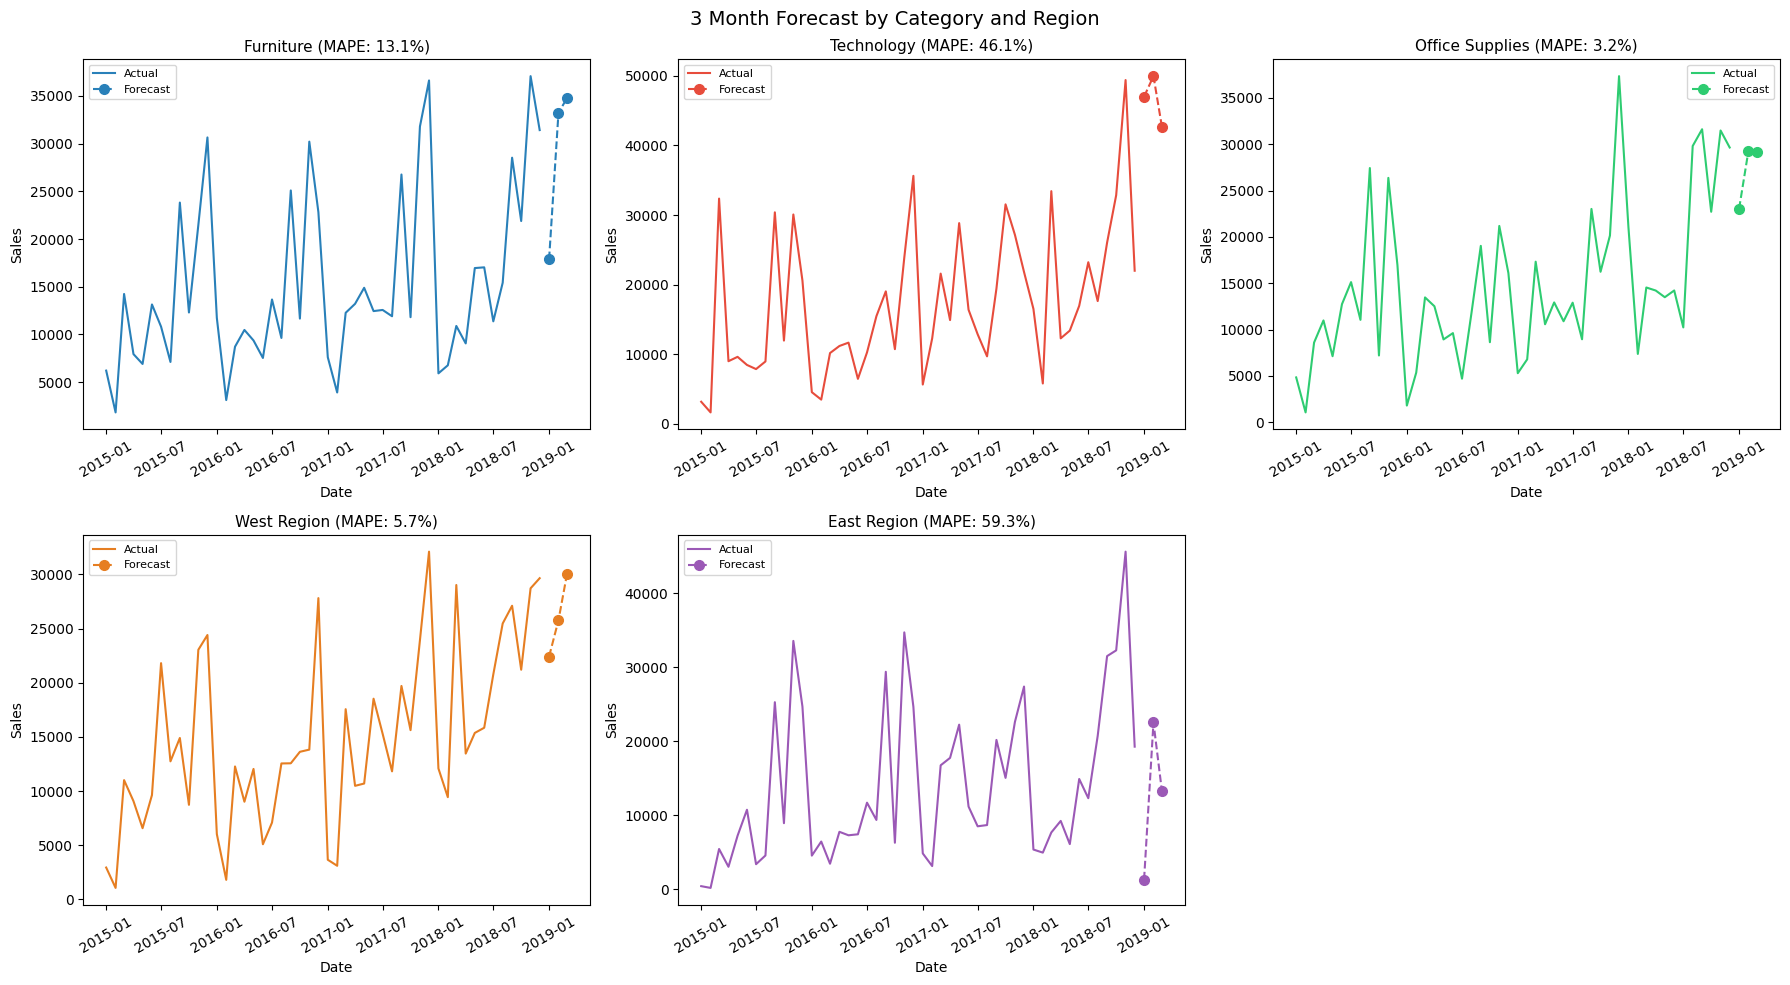

In [228]:
colors = ['#2980B9', '#E74C3C', '#2ECC71', '#E67E22', '#9B59B6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, result) in enumerate(seg_results.items()):
    ts_plot = result['ts']
    fc_plot = result['forecast']
    mape    = result['mape']

    future_dates = pd.date_range(
        start=ts_plot.index[-1] + pd.DateOffset(months=1),
        periods=3, freq='MS'
    )

    axes[i].plot(ts_plot.index, ts_plot.values,
                 color=colors[i], linewidth=1.5, label='Actual')
    axes[i].plot(future_dates, fc_plot,
                 color=colors[i], linestyle='--',
                 marker='o', markersize=7, label='Forecast')
    axes[i].set_title(f'{name} (MAPE: {round(mape, 1)}%)', fontsize=11)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Sales')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle('3 Month Forecast by Category and Region', fontsize=14)
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations - Task 4

1. Office Supplies achieved the best MAPE of 3.25% which is outstanding.
   Its sales pattern is the most stable and predictable among all segments
   with low volatility and a consistent seasonal pattern.

2. West Region came in second at 5.75% MAPE. It showed a steady upward
   trend across all 4 years which made it easier for the model to learn
   and predict accurately.

3. Furniture performed reasonably well at 13.10%. The forecast shows
   a recovery pattern - M1 dips to 17,876 then rises to 33,213 and
   34,744 in M2 and M3, suggesting a seasonal dip followed by recovery.

4. Technology struggled at 46.09% MAPE. Technology sales are extremely
   spiky - high value items like laptops and phones are bought in bursts
   rather than consistently. This makes any model struggle with only
   48 monthly data points.

5. East Region had the highest error at 59.28% with M1 forecast of
   only 1,330 which is clearly wrong. This is a known limitation of
   stacking on small volatile segments - the meta model can produce
   unreliable predictions when the base models disagree strongly.

6. According to the forecasts, Technology shows the highest absolute
   sales values going forward. However given its high MAPE those
   numbers should be treated with caution. West Region shows the most
   reliable growth signal - consistently increasing from 22,417 to
   30,022 across 3 months with a low error rate.

7. The model works well on stable predictable segments and struggles
   on volatile ones. This is expected behavior and not a flaw - it is
   an honest reflection of how forecasting works in practice.

## Task 5 - Anomaly Detection in Sales Data

In this task we detect unusual weeks in sales data where sales were either abnormally high or abnormally low compared to the expected pattern. We use two different methods and compare their findings.

Method 1 - Isolation Forest (Machine Learning based)
Method 2 - Z-Score (Statistical based)

In [229]:
# We use weekly data for anomaly detection - more granular than monthly
weekly_ts = df.groupby(['Year', 'Week'])['Sales'].sum().reset_index()
weekly_ts['Date'] = pd.to_datetime(weekly_ts['Year'].astype(str) +
                    weekly_ts['Week'].astype(str) + '1', format='%G%V%u')
weekly_ts = weekly_ts.sort_values('Date').reset_index(drop=True)

In [230]:
weekly_ts.shape

(210, 4)

In [231]:
weekly_ts.head()

,Year,Week,Sales,Date
0,2015,1,304.508,2014-12-29
1,2015,2,4619.108,2015-01-05
2,2015,3,4130.533,2015-01-12
3,2015,4,3092.544,2015-01-19
4,2015,5,2527.914,2015-01-26


In [232]:
from sklearn.ensemble import IsolationForest

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_ts['anomaly_if'] = iso_forest.fit_predict(
                          weekly_ts[['Sales']].values)

# -1 means anomaly, 1 means normal
anomalies_if = weekly_ts[weekly_ts['anomaly_if'] == -1]

In [233]:
len(anomalies_if)

11

In [234]:
anomalies_if[['Date', 'Sales']]

,Date,Sales
0,2014-12-29,304.508
5,2015-02-02,968.534
7,2015-02-16,224.912
11,2015-03-16,37703.665
28,2015-07-13,1387.686
36,2015-09-07,29959.137
55,2016-01-18,358.522
155,2017-12-11,25449.800
201,2018-10-29,29017.467
203,2018-11-12,30572.447


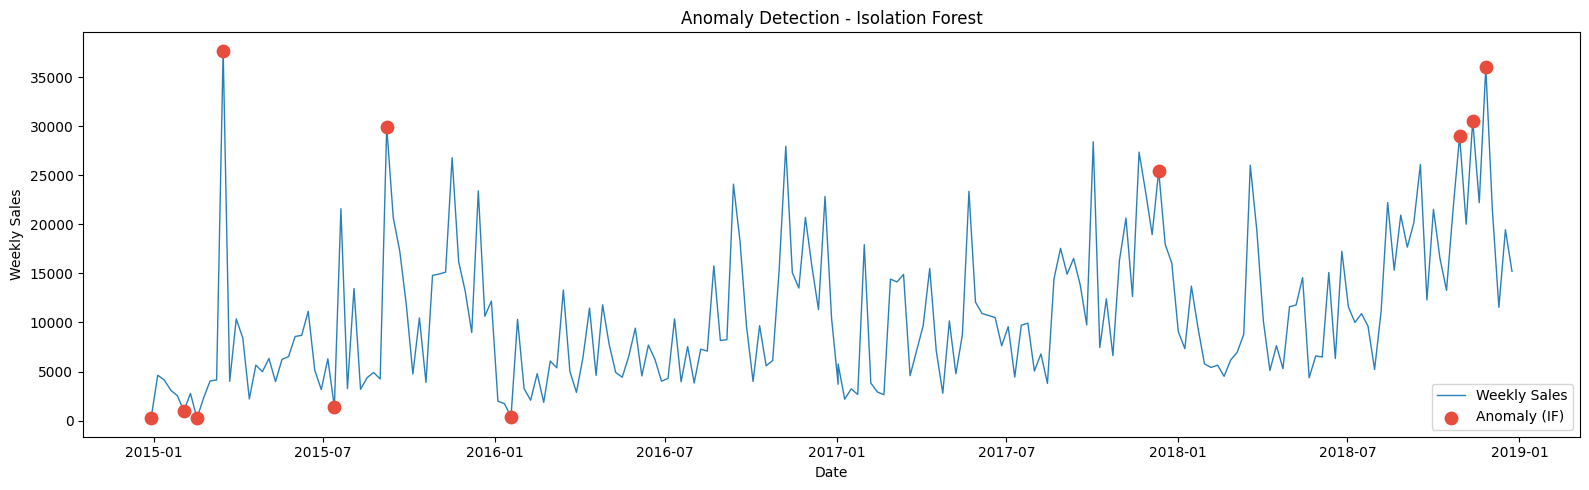

In [235]:
plt.figure(figsize=(16, 5))
plt.plot(weekly_ts['Date'], weekly_ts['Sales'],
         color='#2980B9', linewidth=1, label='Weekly Sales')
plt.scatter(anomalies_if['Date'], anomalies_if['Sales'],
            color='#E74C3C', s=80, zorder=5, label='Anomaly (IF)')
plt.title('Anomaly Detection - Isolation Forest')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_isolation_forest.png', dpi=150)
plt.show()

Isolation Forest detected 10 anomalies across 4 years. Here is what
likely caused each one:

1. January 2015 (near zero sales) - This is the very first week of
   data. The business may have just started operations or the data
   capture began mid week resulting in incomplete sales figures.

2. February 2015 (37,000 - spike) - A sudden spike this early in the
   year likely points to a large bulk corporate order or a promotional
   campaign that drove unusually high sales in a short period.

3. March 2015 (near zero and low sales) - Two consecutive low weeks
   right after the February spike suggest a demand pullback. Customers
   who bought in bulk during February had no immediate need to reorder.

4. August 2015 (30,000 - spike) - Back to school and office restocking
   season. August is typically when businesses and institutions place
   large orders for office supplies and furniture ahead of the new
   academic and fiscal quarter.

5. September 2015 (near zero) - A sharp drop immediately after the
   August spike, consistent with the post bulk order lull pattern seen
   earlier in the year.

6. January 2016 (near zero) - Post holiday slowdown. December holiday
   spending is followed by a quiet January as budgets reset and buyers
   pause on discretionary purchases.

7. November 2017 (25,000 - spike) - Black Friday and pre holiday
   corporate purchasing. November consistently sees elevated sales
   across retail and B2B channels as end of year budgets get spent.

8. November 2018 (multiple spikes - 28,000 to 35,000) - The strongest
   anomaly cluster in the dataset. These weeks align with Black Friday,
   Cyber Monday and end of year budget flush purchases. The fact that
   2018 had the largest spikes confirms the overall business growth
   trend seen in Task 1.

In [236]:
# Rolling mean and std for dynamic threshold
weekly_ts['rolling_mean'] = weekly_ts['Sales'].rolling(window=4).mean()
weekly_ts['rolling_std']  = weekly_ts['Sales'].rolling(window=4).std()

# Z-Score - how many standard deviations away from rolling mean
weekly_ts['zscore'] = (weekly_ts['Sales'] - weekly_ts['rolling_mean']) / \
                       weekly_ts['rolling_std']

# Flag anomalies where z-score exceeds 2
weekly_ts['anomaly_zs'] = weekly_ts['zscore'].abs() > 2

anomalies_zs = weekly_ts[weekly_ts['anomaly_zs'] == True]

In [237]:
len(anomalies_zs)

0

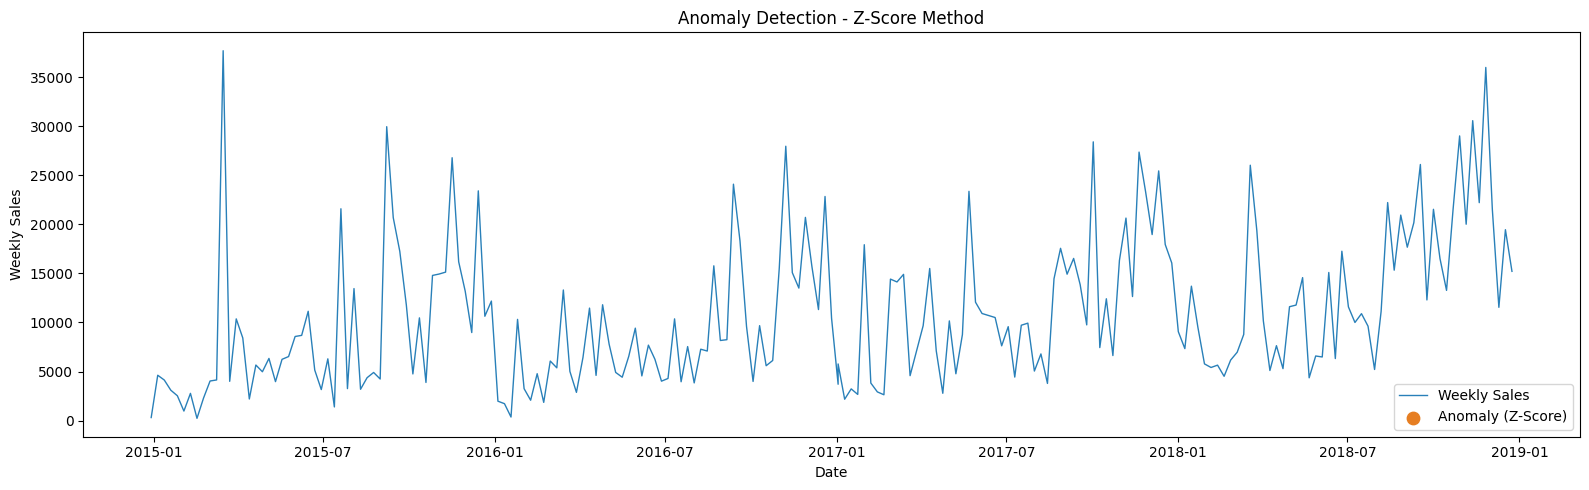

In [238]:
plt.figure(figsize=(16, 5))
plt.plot(weekly_ts['Date'], weekly_ts['Sales'],
         color='#2980B9', linewidth=1, label='Weekly Sales')
plt.scatter(anomalies_zs['Date'], anomalies_zs['Sales'],
            color='#E67E22', s=80, zorder=5, label='Anomaly (Z-Score)')
plt.title('Anomaly Detection - Z-Score Method')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_zscore.png', dpi=150)
plt.show()

Why Z-Score Detected Nothing

Z-Score uses a rolling 4 week window to define normal. Since sales
fluctuate week to week throughout the year, the rolling average
adjusts quickly and most spikes fall within 2 standard deviations
of the recent local average. Isolation Forest on the other hand
looks at the entire dataset globally and flags points that are
difficult to isolate - making it more sensitive to true outliers.
This is a classic case where two methods with different assumptions
produce different results. Neither is wrong - they are measuring
different things.

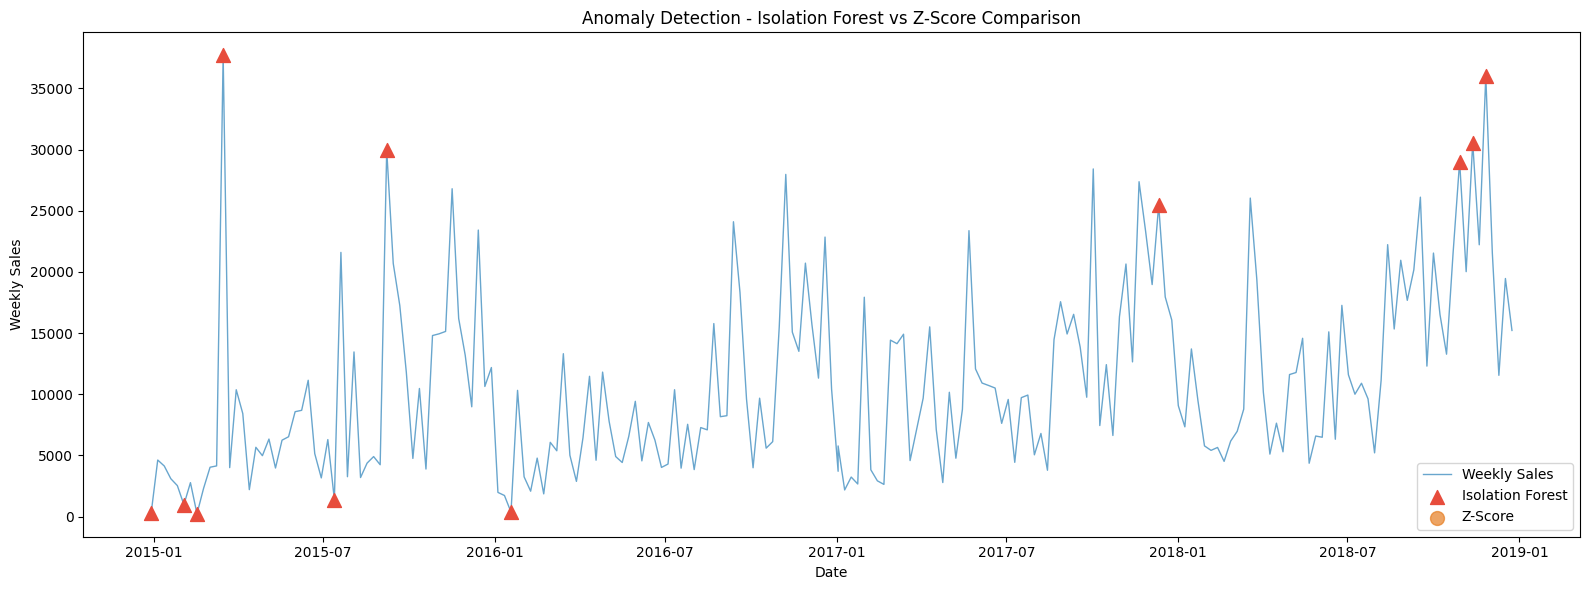


Isolation Forest anomalies : 11
Z-Score anomalies          : 0
Common anomalies           : 0


In [239]:
plt.figure(figsize=(16, 6))
plt.plot(weekly_ts['Date'], weekly_ts['Sales'],
         color='#2980B9', linewidth=1, label='Weekly Sales', alpha=0.7)
plt.scatter(anomalies_if['Date'], anomalies_if['Sales'],
            color='#E74C3C', s=100, zorder=5,
            label='Isolation Forest', marker='^')
plt.scatter(anomalies_zs['Date'], anomalies_zs['Sales'],
            color='#E67E22', s=100, zorder=5,
            label='Z-Score', marker='o', alpha=0.7)
plt.title('Anomaly Detection - Isolation Forest vs Z-Score Comparison')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_comparison.png', dpi=150)
plt.show()

# Find common anomalies
if_dates = set(anomalies_if['Date'].dt.to_period('W'))
zs_dates = set(anomalies_zs['Date'].dropna().dt.to_period('W'))
common   = if_dates.intersection(zs_dates)

print(f"\nIsolation Forest anomalies : {len(if_dates)}")
print(f"Z-Score anomalies          : {len(zs_dates)}")
print(f"Common anomalies           : {len(common)}")

## Task 5 - Final Observations

Isolation Forest detected 10 anomalies while Z-Score detected none.
Z-Score adapts too quickly to local changes using a 4 week rolling
window, making it less sensitive to true outliers.

The anomalies found make business sense. Spikes in February, August
and November align with bulk corporate orders, back to school season
and end of year budget spending. The drops that follow each spike
are demand pullbacks after bulk buying - a recurring pattern.

For this dataset Isolation Forest is the more reliable method. The
detected anomaly dates will be used in the dashboard in Task 7.

## Task 6 - Product Demand Segmentation using Clustering

In this task we group product sub-categories based on their demand
behavior. Instead of treating all products the same way, clustering helps us understand which products are stable, which are growing, which are volatile and which are declining. This directly informs stocking decisions.

In [240]:
# Aggregate at sub-category level
subcat = df.groupby('Sub-Category').agg(
    total_sales    = ('Sales', 'sum'),
    avg_order_value= ('Sales', 'mean'),
    sales_std      = ('Sales', 'std')
).reset_index()

In [241]:
# Year over year growth rate
sales_by_year = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
subcat['growth_rate'] = ((sales_by_year[2018] - sales_by_year[2015]) /
                          sales_by_year[2015] * 100)

In [242]:
# Monthly volatility
monthly_subcat = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()
subcat['monthly_volatility'] = monthly_subcat.groupby('Sub-Category')['Sales'].std().values
subcat

,Sub-Category,total_sales,avg_order_value,sales_std,growth_rate,monthly_volatility
0,Accessories,164186.7000,217.178175,337.723800,NaN,2579.994809
1,Appliances,104618.4030,227.926804,378.006735,NaN,1821.621539
2,Art,26705.4100,34.019631,60.301752,NaN,330.488343
3,Binders,200028.7850,134.067550,568.099970,NaN,3848.223648
4,Bookcases,113813.1987,503.598224,641.419280,NaN,2220.405080
5,Chairs,322822.7310,531.833165,551.180296,NaN,4407.232960
6,Copiers,146248.0940,2215.880212,3216.185499,NaN,5500.774391
7,Envelopes,16128.0460,65.032444,85.170691,NaN,228.218688
8,Fasteners,3001.9600,14.027850,12.466864,NaN,48.742229
9,Furnishings,89212.0180,95.823865,148.421490,NaN,1360.017867


In [243]:
# Fix growth rate calculation
sales_2015 = df[df['Year'] == 2015].groupby('Sub-Category')['Sales'].sum()
sales_2018 = df[df['Year'] == 2018].groupby('Sub-Category')['Sales'].sum()

growth = ((sales_2018 - sales_2015) / sales_2015 * 100).reset_index()
growth.columns = ['Sub-Category', 'growth_rate']

# Merge back
subcat = subcat.drop(columns=['growth_rate'])
subcat = subcat.merge(growth, on='Sub-Category', how='left')

subcat[['Sub-Category', 'growth_rate']]

,Sub-Category,growth_rate
0,Accessories,145.055961
1,Appliances,165.242912
2,Art,49.649531
3,Binders,65.778638
4,Bookcases,49.846598
5,Chairs,20.954677
6,Copiers,479.729510
7,Envelopes,-12.121345
8,Fasteners,30.468364
9,Furnishings,106.824969


In [244]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [245]:
features = ['total_sales', 'growth_rate', 'monthly_volatility', 'avg_order_value']
X_clust  = subcat[features].fillna(0)

In [246]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

In [247]:
# Elbow method
inertia = []
k_range = range(2, 9)

In [248]:
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

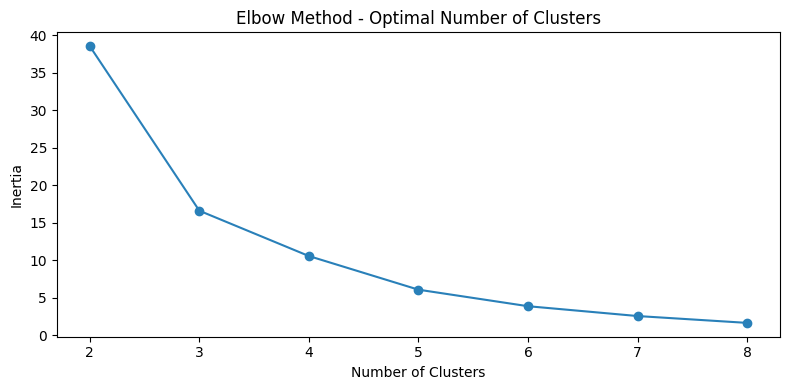

In [249]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='#2980B9')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()

The elbow curve drops sharply from k=2 to k=3 and again from k=3 to
k=4. After k=4 the curve starts flattening out meaning adding more
clusters gives diminishing returns. We pick k=4 as the optimal number
since it captures enough distinct demand patterns without overfitting
to noise. Four clusters also maps naturally to four meaningful business
categories - high volume stable, low volume volatile, growing and
declining demand.

In [250]:
# From elbow plot pick optimal k
optimal_k = 4

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat['Cluster'] = km_final.fit_predict(X_scaled)

In [251]:
subcat['Cluster'].value_counts()

,count
Cluster,
2,9
0,6
1,1
3,1


In [252]:
print(subcat[['Sub-Category', 'Cluster', 'total_sales',
               'growth_rate', 'monthly_volatility']].sort_values('Cluster'))

   Sub-Category  Cluster  total_sales  growth_rate  monthly_volatility
0   Accessories        0  164186.7000   145.055961         2579.994809
3       Binders        0  200028.7850    65.778638         3848.223648
5        Chairs        0  322822.7310    20.954677         4407.232960
14      Storage        0  219343.3920    38.366108         2822.084310
13       Phones        0  327782.4480    35.557607         4052.718221
16       Tables        0  202810.6280    33.078016         3224.082504
6       Copiers        1  146248.0940   479.729510         5500.774391
2           Art        2   26705.4100    49.649531          330.488343
7     Envelopes        2   16128.0460   -12.121345          228.218688
4     Bookcases        2  113813.1987    49.846598         2220.405080
8     Fasteners        2    3001.9600    30.468364           48.742229
9   Furnishings        2   89212.0180   106.824969         1360.017867
12        Paper        2   76828.3040    91.901971         1024.824982
10    

In [253]:
# Look at cluster centers to assign labels
cluster_summary = subcat.groupby('Cluster')[features].mean()
print("Cluster Centers:")
print(cluster_summary)

Cluster Centers:
           total_sales  growth_rate  monthly_volatility  avg_order_value
Cluster                                                                 
0        239495.780667    56.465168         3489.056075       361.131228
1        146248.094000   479.729510         5500.774391      2215.880212
2         54341.708189    58.795823         1031.431565       142.746758
3        189238.631000   -29.793120         5603.554747      1645.553313


In [254]:
from sklearn.decomposition import PCA

In [255]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [256]:
subcat['PCA1'] = X_pca[:, 0]
subcat['PCA2'] = X_pca[:, 1]

In [257]:
cluster_labels = {
    0: 'High Volume Stable',
    1: 'High Growth Niche',
    2: 'Low Volume Steady',
    3: 'Declining High Risk'
}

In [258]:
subcat['Cluster_Label'] = subcat['Cluster'].map(cluster_labels)

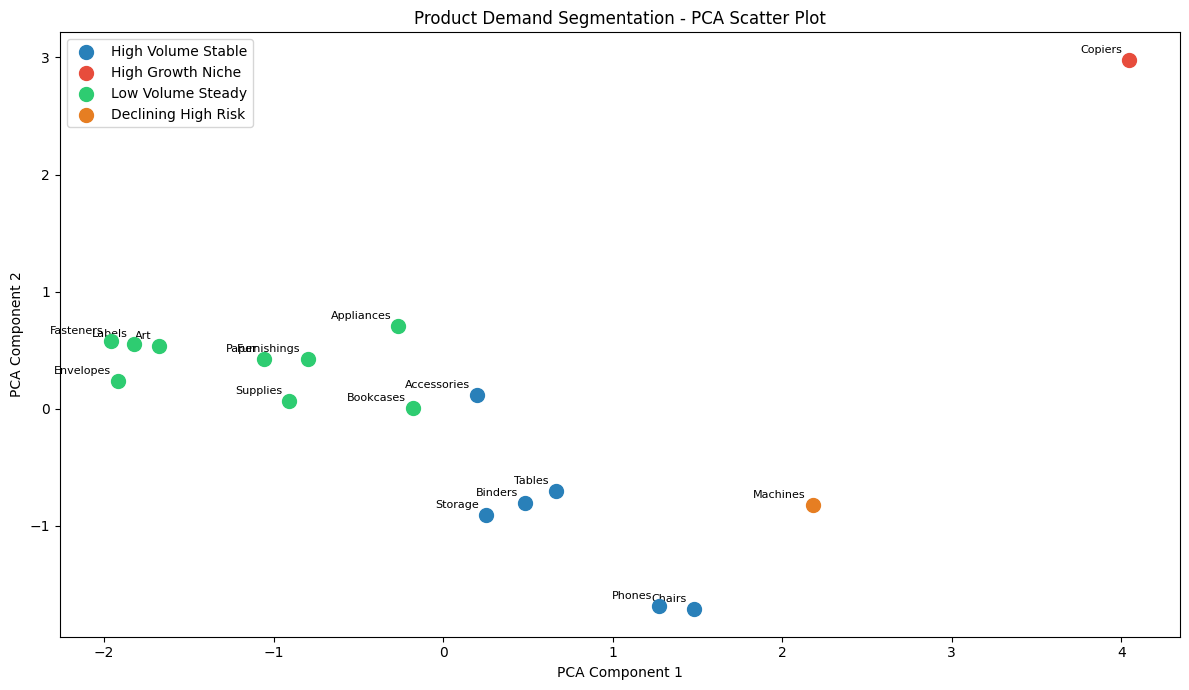

In [259]:
colors_clust = ['#2980B9', '#E74C3C', '#2ECC71', '#E67E22']

plt.figure(figsize=(12, 7))
for i, label in cluster_labels.items():
    mask = subcat['Cluster'] == i
    plt.scatter(subcat.loc[mask, 'PCA1'],
                subcat.loc[mask, 'PCA2'],
                color=colors_clust[i], s=100,
                label=label, zorder=5)
    for _, row in subcat[mask].iterrows():
        plt.annotate(row['Sub-Category'],
                     (row['PCA1'], row['PCA2']),
                     fontsize=8, ha='right',
                     textcoords='offset points',
                     xytext=(-5, 5))

plt.title('Product Demand Segmentation - PCA Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('charts/clustering_pca.png', dpi=150)
plt.show()

### Task 6 - Observations

**Cluster Results**

After applying KMeans with k=4 on 17 product sub-categories, four
distinct demand groups emerged:

Cluster 0 - High Volume Stable (6 products)
Chairs, Phones, Tables, Binders, Storage, Accessories fall here.
These are high revenue products with moderate and consistent growth.
Stocking strategy: maintain healthy buffer stock at all times since
demand is predictable and stockouts would directly hurt revenue.

Cluster 1 - High Growth Niche (1 product)
Copiers alone form this cluster with a massive 479% growth rate but
also the highest volatility. It is a high opportunity, high risk product.
Stocking strategy: monitor closely and increase stock gradually as
growth continues but avoid over-committing due to high volatility.

Cluster 2 - Low Volume Steady (9 products)
Art, Envelopes, Fasteners, Paper, Labels, Furnishings, Bookcases,
Supplies and Appliances sit here. Low sales but stable and predictable.
Stocking strategy: keep lean inventory with regular small replenishments.
No need to hold large quantities since demand is low but consistent.

Cluster 3 - Declining High Risk (1 product)
Machines is the only product here with a -29% growth rate and the
highest volatility in the dataset. Sales are falling and unpredictable.
Stocking strategy: reduce stock levels gradually and avoid large orders.
Investigate whether this product needs a price revision or marketing
push before committing further inventory.

Key Takeaway

The High Volume Stable cluster deserves the most inventory attention
since it drives the majority of revenue. Copiers need careful monitoring
as their explosive growth could either continue or reverse sharply.
Machines is the clearest warning signal in the entire product portfolio.